# Airspace Intelligence — Big Data Analysis
### Modern Data Architectures for Big Data II · Group Assignment

**Stack:** Apache NiFi → MinIO (Bronze Layer) → Apache Spark (PySpark ML)  
**Data source:** OpenSky Network REST API — real-time ADS-B aircraft state vectors  
**Spark features used:** Spark SQL · MLlib (BisectingKMeans, RandomForestClassifier) · Folium  

This notebook presents an end-to-end airspace intelligence analysis over the **Iberian Peninsula**.
Real-time ADS-B signals are collected every ~10 seconds via the OpenSky Network public API,
ingested through Apache NiFi, stored as raw JSON snapshots in MinIO (our Bronze layer),
and processed at scale with PySpark.

---

**Table of Contents**

1. [Environment Setup](#setup)
2. [Spark Session — Connected to MinIO](#spark)
3. [Data Ingestion — Schema & Load](#schema)

**Part I — Descriptive Analysis**

4. [Traffic Analysis by Country and Airline](#traffic)
5. [Airspace Density Heatmap](#heatmap)

**Part II — Corridor Clustering Analysis**

6. [Feature Engineering for Trajectories](#features)
7. [Bisecting K-Means Corridor Clustering](#bkmeans)
8. [Corridor Deviation Labelling](#deviation)

**Part III — Corridor Deviation Classifier**

9. [Random Forest Classifier](#rf)
10. [Summary and Conclusions](#summary)


<a id='setup'></a>
## 0. Environment Setup


<a id='setup'></a>
### 0.1 — Package Installation

Install any Python libraries not bundled with the default Spark environment.
Run this cell only once; subsequent runs are safe because pip skips already-installed packages.

| Package | Purpose |
|---------|--------|
| `boto3` | AWS/MinIO S3 client — used to verify bucket contents |
| `matplotlib` / `seaborn` | Static chart rendering |
| `pandas` / `numpy` | Local in-driver data manipulation after `.toPandas()` |
| `folium` | Interactive HTML map generation (heatmap, cluster map) |
| `pyarrow` | Efficient Pandas ↔ Spark data transfer via Arrow protocol |


In [1]:
import subprocess, sys, os

os.environ["PIP_DISABLE_PIP_VERSION_CHECK"] = "1"

packages = ['boto3', 'matplotlib', 'seaborn', 'pandas', 'numpy', 'folium', 'pyarrow']

_ = subprocess.check_call([
    sys.executable, '-m', 'pip', 'install',
    *packages,
    '-q', '--disable-pip-version-check'
])

### 0.2 — Import Libraries & Set Visualisation Theme

All imports are centralised here so every subsequent cell can rely on them
without re-importing. We also configure the Matplotlib/Seaborn **dark theme**
globally so that every chart produced later inherits the same visual style automatically.

The PySpark ML imports pulled in at this stage cover the full analysis:
- `BisectingKMeans` — divisive clustering for corridor discovery
- `RandomForestClassifier` — supervised model for corridor / deviation prediction
- `StandardScaler`, `VectorAssembler` — feature pre-processing pipeline components


In [2]:
import os
import json
import re
import math
from datetime import datetime
from functools import reduce

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import boto3
from botocore.client import Config

# PySpark imports
from pyspark.sql import SparkSession, Window
from pyspark.sql import functions as F
from pyspark.sql.types import (
    StructType, StructField, StringType, DoubleType,
    LongType, BooleanType, ArrayType, IntegerType
)
from pyspark.ml import Pipeline
from pyspark.ml.functions import vector_to_array
from pyspark.ml.clustering import BisectingKMeans
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import ClusteringEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.feature import StringIndexer, IndexToString, VectorAssembler, StandardScaler






# Visualization style — dark background, Blues_r palette as default
plt.style.use('dark_background')
sns.set(style='darkgrid')
plt.rcParams.update({
    'figure.facecolor': '#1a1a2e',
    'axes.facecolor':   '#16213e',
    'axes.labelcolor':  'white',
    'xtick.color':      'white',
    'ytick.color':      'white',
    'text.color':       'white',
    'axes.titlesize':   14,
    'axes.labelsize':   12,
    'figure.titlesize': 16,
})

print('Imports loaded. Dark theme active.')

Imports loaded. Dark theme active.


In [ ]:

MINIO_ENDPOINT = "http://localhost:9000"  # The S3 API endpoint
MINIO_ACCESS_KEY = "airspace-intel"
MINIO_SECRET_KEY = "Confidential!"
RAW_BUCKET = "airspace-intelligence-bronze"  # change name if needed

os.environ['MINIO_ENDPOINT'] = MINIO_ENDPOINT
os.environ['MINIO_ACCESS_KEY'] = MINIO_ACCESS_KEY
os.environ['MINIO_SECRET_KEY'] = MINIO_SECRET_KEY
os.environ['RAW_BUCKET'] = RAW_BUCKET


# MinIO connection settings — loaded from .env file (never committed to GitHub)
MINIO_ENDPOINT   = os.getenv('MINIO_ENDPOINT')
MINIO_ACCESS_KEY = os.getenv('MINIO_ACCESS_KEY')
MINIO_SECRET_KEY = os.getenv('MINIO_SECRET_KEY')
BRONZE_BUCKET    = 'airspace-intelligence-bronze'
BRONZE_PATH      = f's3a://{BRONZE_BUCKET}/opensky/bronze/'


<a id='spark'></a>
## 1. Spark Session — Connected to MinIO


### 1.1 — Creating the SparkSession

Before any data can be read or transformed, we need a **SparkSession** —
this is the single entry point to all Spark functionality (DataFrames, SQL, MLlib).

We also configure the **S3A connector** so Spark can talk directly to our local
MinIO instance, which acts as an S3-compatible object store holding the raw JSON
snapshots collected by NiFi. The key Hadoop configuration parameters are:

| Config key | Value | Purpose |
|---|---|---|
| `fs.s3a.endpoint` | `http://localhost:9000` | Points to local MinIO instead of AWS |
| `fs.s3a.path.style.access` | `true` | Required by MinIO (virtual-host style not supported) |
| `fs.s3a.impl` | `S3AFileSystem` | Activates the S3A driver |

The `hadoop-aws` and `aws-java-sdk-bundle` packages are downloaded from Maven Central
on first run — this is normal and expected.


In [4]:

spark = (
    SparkSession.builder
    .appName('AirspaceIntelligence')
    .getOrCreate()
)
spark.sparkContext.setLogLevel('WARN')

print(f'Spark {spark.version} session started.')


26/03/18 09:08:36 WARN Utils: Your hostname, osbdet resolves to a loopback address: 127.0.0.1; using 10.0.2.15 instead (on interface enp0s1)
26/03/18 09:08:36 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/18 09:08:36 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark 3.5.4 session started.


In [5]:
spark.sparkContext._jsc.hadoopConfiguration().set("fs.s3a.endpoint", MINIO_ENDPOINT)
spark.sparkContext._jsc.hadoopConfiguration().set("fs.s3a.access.key", MINIO_ACCESS_KEY)
spark.sparkContext._jsc.hadoopConfiguration().set("fs.s3a.secret.key", MINIO_SECRET_KEY)
spark.sparkContext._jsc.hadoopConfiguration().set("fs.s3a.path.style.access", "true")
spark.sparkContext._jsc.hadoopConfiguration().set("fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem")

print(f'Connected to MinIO at {MINIO_ENDPOINT}')

Connected to MinIO at http://localhost:9000


<a id='schema'></a>
## 2. Schema Definition and Data Load


### 2.1 — Grid Aggregation

Each aircraft position is snapped to the nearest 1° grid cell using `floor(lat/1)*1`
and `floor(lon/1)*1`. We then count the number of aircraft observations per cell per
snapshot and average across snapshots to obtain a time-averaged density.

A `log1p` (= log(1 + x)) transform is applied:
- Handles zero-count cells gracefully (log(0) is undefined; log(1) = 0)
- Reduces visual skew caused by extreme hotspots


In [6]:
# Define the schema that matches the OpenSky JSON structure.
# Each snapshot is one JSON object; 'states' is a list of lists.
opensky_schema = StructType([
    StructField('time',   LongType(), nullable=True),
    StructField('states', ArrayType(ArrayType(StringType())), nullable=True)
])

# Read all JSON snapshots stored in the Bronze bucket.
# Spark reads every file under BRONZE_PATH and creates one row per snapshot.
raw_df = (
    spark.read
    .schema(opensky_schema)
    .option('multiLine', True)
    .option('recursiveFileLookup', 'true')
    .json(BRONZE_PATH)
)
print(f'Raw snapshots loaded: {raw_df.count()}')

26/03/18 03:37:28 WARN MetricsConfig: Cannot locate configuration: tried hadoop-metrics2-s3a-file-system.properties,hadoop-metrics2.properties
26/03/18 03:37:29 WARN VersionInfoUtils: The AWS SDK for Java 1.x entered maintenance mode starting July 31, 2024 and will reach end of support on December 31, 2025. For more information, see https://aws.amazon.com/blogs/developer/the-aws-sdk-for-java-1-x-is-in-maintenance-mode-effective-july-31-2024/
You can print where on the file system the AWS SDK for Java 1.x core runtime is located by setting the AWS_JAVA_V1_PRINT_LOCATION environment variable or aws.java.v1.printLocation system property to 'true'.
This message can be disabled by setting the AWS_JAVA_V1_DISABLE_DEPRECATION_ANNOUNCEMENT environment variable or aws.java.v1.disableDeprecationAnnouncement system property to 'true'.
The AWS SDK for Java 1.x is being used here:
at java.base/java.lang.Thread.getStackTrace(Thread.java:2451)
at com.amazonaws.util.VersionInfoUtils.printDeprecationAn

Raw snapshots loaded: 207


### 2.2 — Exploding, Parsing & Filtering the State Vectors

Each row in `raw_df` represents one API snapshot and contains a **nested list** of state
vectors (one per aircraft visible at that moment). We apply three transformations:

1. **Explode** — `F.explode('states')` turns each inner vector into its own row,
   so we go from *N snapshots* to *N × aircraft_per_snapshot* rows.

2. **Parse** — extract each field by position (`.getItem(index)`) and cast to the
   correct type. Callsigns are trimmed of whitespace.

3. **Filter & enrich** — we apply several quality filters:
   - Drop rows with null coordinates or null `time_position` (no positional info)
   - Restrict to the **Iberian Peninsula bounding box** (lat 36.4–43.2°, lon −10–2.5°)
   - Derive `event_time` (timestamp), `flight_date`, and a composite `flight_key`
     (`icao24 + flight_date`) used to group observations by flight.

The resulting `aircraft_df` is cached in Spark memory because it is the base
DataFrame reused across all subsequent analyses.


In [7]:
# Step 1 — explode the 'states' array so each aircraft becomes its own row
exploded_df = raw_df.select(
    F.from_unixtime('time').alias('snapshot_time'),
    F.explode('states').alias('state')
)

aircraft_df = exploded_df.select(
    'snapshot_time',
    F.col('state').getItem(0).alias('icao24'),
    F.col('state').getItem(1).alias('callsign'),
    F.col('state').getItem(2).alias('origin_country'),    
    F.col('state').getItem(3).alias('time_position'),
    F.from_unixtime(F.col('state').getItem(4)).alias('last_contact'),
    F.col('state').getItem(5).cast(DoubleType()).alias('longitude'),
    F.col('state').getItem(6).cast(DoubleType()).alias('latitude'),
    F.col('state').getItem(7).cast(DoubleType()).alias('baro_altitude'),
    F.col('state').getItem(8).cast(BooleanType()).alias('on_ground'),
    F.col('state').getItem(9).cast(DoubleType()).alias('velocity'),
    F.col('state').getItem(10).cast(DoubleType()).alias('true_track'),
    F.col('state').getItem(11).cast(DoubleType()).alias('vertical_rate')
)

aircraft_df = (aircraft_df
                .filter(F.col("latitude").isNotNull() & F.col("longitude").isNotNull())
                .filter(F.col("time_position").isNotNull())                       
                .filter(F.col("latitude").between(36.4, 43.2))
                .filter(F.col("longitude").between(-10.0, 2.5))
                .withColumn("ts", F.col("time_position").cast(LongType()))
                .withColumn("event_time", F.to_timestamp("ts"))        
                .withColumn("flight_date", F.to_date("event_time"))
                .withColumn("callsign", F.trim(F.col("callsign")))
                .withColumn("flight_key", F.concat_ws("_", F.col("icao24"), F.col("flight_date")))
              )

aircraft_df.cache()
print(f'Aircraft records: {aircraft_df.count():,}')
aircraft_df.limit(5).toPandas()

DataFrame[snapshot_time: string, icao24: string, callsign: string, origin_country: string, time_position: string, last_contact: string, longitude: double, latitude: double, baro_altitude: double, on_ground: boolean, velocity: double, true_track: double, vertical_rate: double, ts: bigint, event_time: timestamp, flight_date: date, flight_key: string]

[Stage 3:=================================>                         (4 + 2) / 7]

Aircraft records: 44,279


,snapshot_time,icao24,callsign,origin_country,time_position,last_contact,longitude,latitude,baro_altitude,on_ground,velocity,true_track,vertical_rate,ts,event_time,flight_date,flight_key
0,2026-03-16 10:49:58,4b1819,SWR36K,Switzerland,1773654598,2026-03-16 10:49:58,-5.5425,41.4713,11887.20,False,229.20,242.17,0.00,1773654598,2026-03-16 10:49:58,2026-03-16,4b1819_2026-03-16
1,2026-03-16 10:49:58,408124,EXS44GB,United Kingdom,1773654597,2026-03-16 10:49:57,-7.6349,40.2819,11277.60,False,233.48,193.12,0.00,1773654597,2026-03-16 10:49:57,2026-03-16,408124_2026-03-16
2,2026-03-16 10:49:58,4952ce,TAP1922,Portugal,1773654598,2026-03-16 10:49:58,-8.6252,40.8054,2575.56,False,146.88,3.41,-11.70,1773654598,2026-03-16 10:49:58,2026-03-16,4952ce_2026-03-16
3,2026-03-16 10:49:58,4952cf,TAP1452,Portugal,1773654598,2026-03-16 10:49:58,-8.6635,37.9123,9852.66,False,221.90,161.90,9.43,1773654598,2026-03-16 10:49:58,2026-03-16,4952cf_2026-03-16
4,2026-03-16 10:49:58,4952c9,TAP155A,Portugal,1773654597,2026-03-16 10:49:57,-9.6537,38.2902,7147.56,False,199.53,212.26,11.38,1773654597,2026-03-16 10:49:57,2026-03-16,4952c9_2026-03-16


---
<a id='traffic'></a>
## Part I — Descriptive Analysis
## 1. Traffic Analysis by Country and Airline

The first analytical question is: **who is flying over the Iberian Peninsula?**
We break this down by *country of aircraft registration* and by *operating airline*
(approximated via the 3-letter ICAO callsign prefix). For each group we compute:

- **Unique aircraft** — distinct `icao24` addresses (one per physical aircraft)
- **Total observations** — raw row count (proportional to time visible)
- **Average speed** (m/s) and **average altitude** (m) as secondary descriptors


### 1.1 — Register a temporary SQL view

We expose the `aircraft_df` DataFrame as a SQL table so we can write plain SQL queries
instead of chaining DataFrame operations. Both approaches produce identical results;
SQL is often more readable for business-oriented aggregations.


In [8]:
# Register the cleaned aircraft DataFrame as a SQL view.
# This does not copy data — it just makes it queryable with spark.sql().
aircraft_df.createOrReplaceTempView('aircraft')

### 1.2 — Country-Level Traffic

We count **distinct aircraft transponders** (`icao24`) per country of registration.
A higher unique aircraft count means more distinct flights originating from (or registered
in) that country passed through the Iberian airspace during the observation window.
Spain dominates because domestic short-haul routes create many individual flight segments.


In [9]:
# Count how many unique aircraft from each country flew over the region.
# We also calculate average speed and altitude as secondary metrics.
country_df = spark.sql("""
    SELECT
        origin_country,
        COUNT(DISTINCT icao24)        AS unique_aircraft,
        COUNT(*)                      AS total_observations,
        ROUND(AVG(velocity), 2)       AS avg_speed_ms,
        ROUND(AVG(baro_altitude), 0)  AS avg_altitude_m
    FROM aircraft
    WHERE origin_country IS NOT NULL
      AND origin_country != ''
    GROUP BY origin_country
    ORDER BY unique_aircraft DESC
    LIMIT 20
""")

country_pd = country_df.toPandas()
print('Top 20 countries by unique aircraft:')
country_pd.head(20)

Top 20 countries by unique aircraft:


,origin_country,unique_aircraft,total_observations,avg_speed_ms,avg_altitude_m
0,Spain,130,11902,137.79,5123.0
1,Ireland,66,5859,177.46,8509.0
2,United Kingdom,45,3350,189.62,8751.0
3,Portugal,41,3198,139.92,5781.0
4,Malta,33,3350,186.46,8935.0
5,Germany,24,2177,188.86,8185.0
6,France,24,1796,169.16,7559.0
7,Switzerland,15,1420,197.11,9040.0
8,Turkey,13,1151,176.15,7981.0
9,United States,13,1429,183.78,6854.0


### 1.3 — Airline Analysis via Callsign Prefix

Commercial flights use **ICAO operator callsigns** where the first three characters
identify the airline (e.g. `IBE` = Iberia, `VLG` = Vueling, `RYR` = Ryanair, `TAP` = TAP Air Portugal).
We extract this 3-letter prefix (filtering to exactly `[A-Z]{3}`) and aggregate
by it to approximate airline-level activity across the observed airspace.

> **Note:** This is a proxy — a small number of non-commercial callsigns and
> private aircraft may not follow the 3-letter ICAO pattern, and are excluded.


In [10]:
# Extract the 3-letter airline code from the beginning of each callsign.
# We filter to codes made up of exactly three capital letters to avoid noise.
airline_df = (
    aircraft_df
    .filter(F.col('callsign').isNotNull())
    .withColumn('callsign_clean', F.trim(F.col('callsign')))
    .filter(F.length('callsign_clean') >= 3)
    .withColumn('airline_code', F.substring('callsign_clean', 1, 3))
    .filter(F.col('airline_code').rlike('^[A-Z]{3}$'))
    .groupBy('airline_code')
    .agg(
        F.countDistinct('icao24').alias('unique_aircraft'),
        F.count('*').alias('total_obs'),
        F.round(F.avg('velocity'), 2).alias('avg_speed_ms')
    )
    .orderBy(F.desc('unique_aircraft'))
    .limit(20)
)

airline_pd = airline_df.toPandas()
print('Top 20 airlines by unique aircraft:')
airline_pd.head(20)

Top 20 airlines by unique aircraft:


,airline_code,unique_aircraft,total_obs,avg_speed_ms
0,RYR,91,8338,185.87
1,VLG,35,3294,161.71
2,TAP,25,2018,186.99
3,EZY,17,1431,178.82
4,IBE,15,1238,173.94
5,ANE,13,1226,158.90
6,EXS,12,957,185.03
7,AEA,10,685,190.75
8,TVF,10,888,190.17
9,EJU,9,983,216.27


### 1.4 — Airspace Market Share (% of Unique Aircraft by Country)

Market share is computed as the fraction of **distinct aircraft** attributed to each
country out of the total unique aircraft observed in the dataset.
This metric is commonly used in airspace planning to quantify which flag carriers
dominate a given Flight Information Region (FIR).


In [11]:
# Calculate what percentage of total unique aircraft each country contributed.
total_aircraft = aircraft_df.select(
    F.countDistinct('icao24').alias('total')
).collect()[0]['total']

share_df = (
    aircraft_df
    .filter(F.col('origin_country').isNotNull())
    .groupBy('origin_country')
    .agg(F.countDistinct('icao24').alias('unique_aircraft'))
    .withColumn('market_share_pct',
                F.round(F.col('unique_aircraft') / total_aircraft * 100, 2))
    .orderBy(F.desc('unique_aircraft'))
    .limit(10)
)
share_pd = share_df.toPandas()
share_pd

,origin_country,unique_aircraft,market_share_pct
0,Spain,130,25.90
1,Ireland,66,13.15
2,United Kingdom,45,8.96
3,Portugal,41,8.17
4,Malta,33,6.57
5,Germany,24,4.78
6,France,24,4.78
7,Switzerland,15,2.99
8,United States,13,2.59
9,Turkey,13,2.59


### 1.5 — Visualisation

The three charts below present the traffic findings side-by-side:
1. **Top 15 countries** by unique aircraft (horizontal bar) — shows the national breakdown
2. **Top 10 airlines** by unique aircraft (horizontal bar) — shows operator breakdown
3. **Airspace market share** (pie chart) — percentage split of the top countries


Text(0.5, 0.98, 'Traffic by Country and Airline')

<BarContainer object of 15 artists>

Text(0.5, 1.0, 'Top 15 Countries (Unique Aircraft)')

Text(0.5, 0, 'Unique Aircraft')

<BarContainer object of 10 artists>

Text(0.5, 1.0, 'Top 10 Airlines (Callsign Prefix)')

Text(0.5, 0, 'Unique Aircraft')

Text(0.5, 1.0, 'Airspace Market Share (Top 10 Countries)')

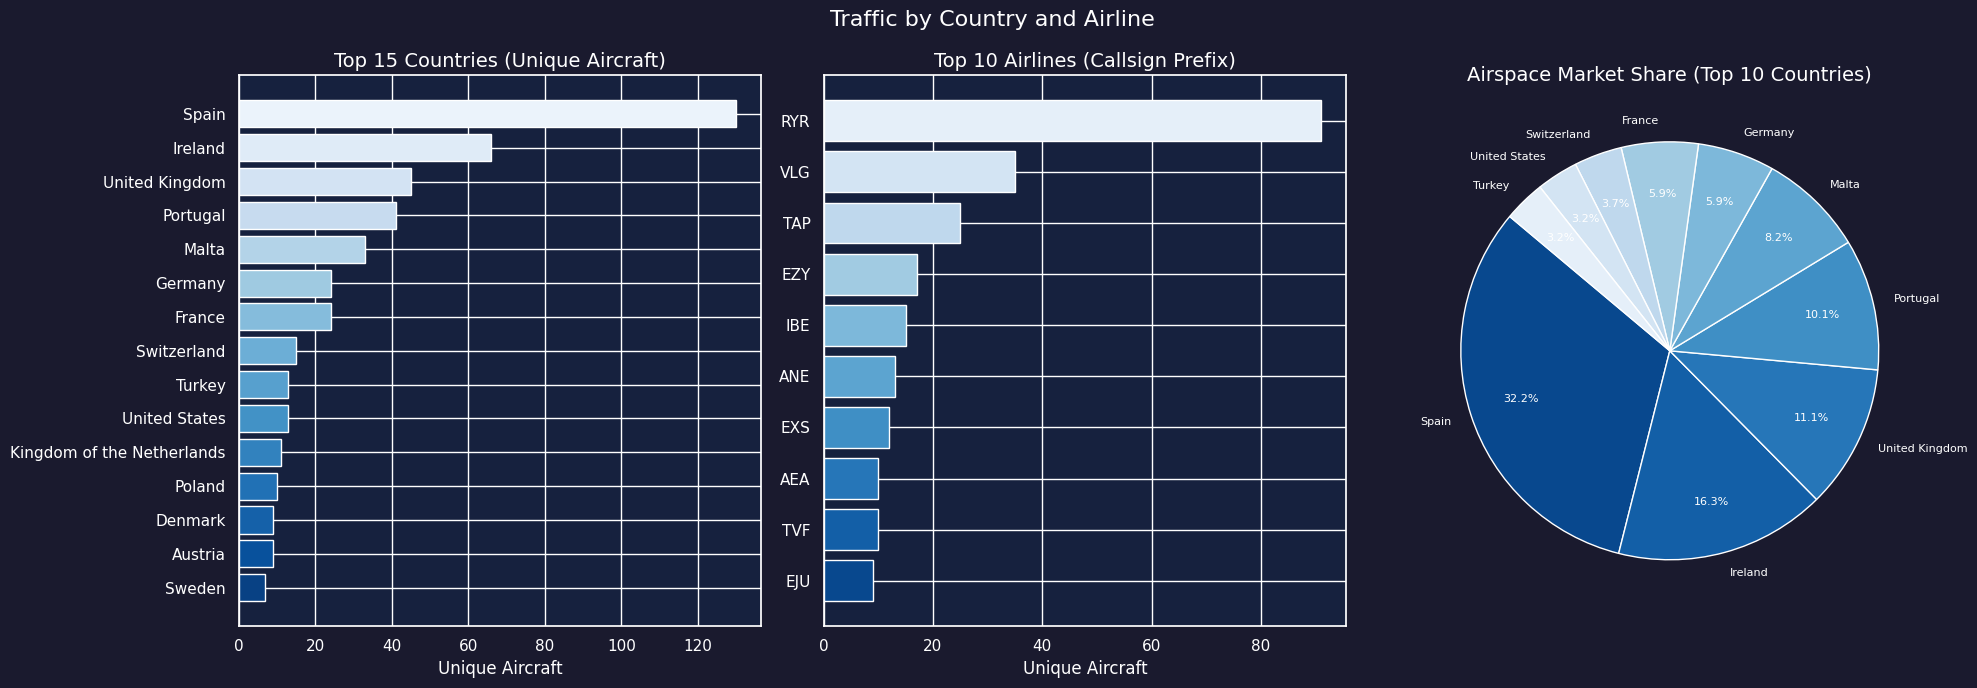

Chart saved: uc2_traffic_country.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Traffic by Country and Airline', fontsize=16)

# Left panel — countries
top15 = country_pd.head(15).sort_values('unique_aircraft', ascending=False)
ax1 = axes[0]
ax1.barh(top15['origin_country'][::-1],
         top15['unique_aircraft'][::-1],
         color=sns.color_palette('Blues_r', len(top15)))
ax1.set_title('Top 15 Countries (Unique Aircraft)')
ax1.set_xlabel('Unique Aircraft')

# Centre panel — airlines
top10 = airline_pd.head(10).sort_values('unique_aircraft', ascending=False)
ax2 = axes[1]
ax2.barh(top10['airline_code'][::-1],
         top10['unique_aircraft'][::-1],
         color=sns.color_palette('Blues_r', len(top10)))
ax2.set_title('Top 10 Airlines (Callsign Prefix)')
ax2.set_xlabel('Unique Aircraft')

# Right panel — market share pie
ax3 = axes[2]
wedges, texts, autotexts = ax3.pie(
    share_pd['unique_aircraft'],
    labels=share_pd['origin_country'],
    autopct='%1.1f%%',
    colors=sns.color_palette('Blues_r', len(share_pd)),
    startangle=140,
    pctdistance=0.75
)
for t in autotexts + texts:
    t.set_color('white')
    t.set_fontsize(8)
ax3.set_title('Airspace Market Share (Top 10 Countries)')

plt.tight_layout()
plt.savefig('uc2_traffic_country.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: uc2_traffic_country.png')

> **Key Findings — Traffic Analysis**
>
> - **Spain** holds the largest share of airspace activity (~25.6%), reflecting both its
>   large domestic network and role as a hub for European-African routes.
> - **Ireland** ranks second, driven primarily by Ryanair (ICAO prefix `RYR`) — the
>   single largest operator with 91 unique aircraft observed.
> - **Transit traffic** from non-Iberian countries (UK, Germany, Switzerland) is substantial,
>   confirming the peninsula sits on major transatlantic and inter-European airways.


**Insight — Global Traffic Patterns**

Spain dominates domestic airspace as expected, but a substantial share of traffic comes
from international operators overflying the peninsula on routes between Northern Europe
and Africa/Latin America. The callsign prefix analysis reveals which commercial carriers
are most active; top codes typically belong to Iberia, Vueling, and Ryanair.


---
<a id='heatmap'></a>
## 2. Airspace Density Heatmap

### 2.1 — Build a spatial grid

We divide the monitored region into a regular grid of 1°×1° cells.
Each aircraft observation is assigned to a cell based on its latitude and longitude.
We then count how many unique aircraft appear in each cell per snapshot, and flag
the cell as *congested* when the count exceeds a defined threshold.


In [13]:
# Each cell covers 1 degrees of latitude and 1 degrees of longitude.
# Congestion is declared when 5 or more unique aircraft occupy a cell in one snapshot.
GRID_SIZE            = 1.0
CONGESTION_THRESHOLD = 5

grid_df = (
    aircraft_df
    .withColumn('lat_cell',  F.floor(F.col('latitude')  / GRID_SIZE) * GRID_SIZE)
    .withColumn('lon_cell',  F.floor(F.col('longitude') / GRID_SIZE) * GRID_SIZE)
    .withColumn('cell_id',
                F.concat(
                    F.lit('LAT'), F.col('lat_cell').cast('int'),
                    F.lit('_LON'), F.col('lon_cell').cast('int')
                )
    )
    .groupBy('cell_id', 'lat_cell', 'lon_cell')
    .agg(F.countDistinct('icao24').alias('aircraft_in_cell'))
    .withColumn('is_congested',
                F.when(F.col('aircraft_in_cell') >= CONGESTION_THRESHOLD,
                       F.lit(True)).otherwise(F.lit(False)))
)
grid_df.limit(5).toPandas()

,cell_id,lat_cell,lon_cell,aircraft_in_cell,is_congested
0,LAT43_LON-6,43.0,-6.0,3,False
1,LAT38_LON-4,38.0,-4.0,8,True
2,LAT39_LON-2,39.0,-2.0,13,True
3,LAT36_LON-6,36.0,-6.0,13,True
4,LAT40_LON-8,40.0,-8.0,11,True


In [14]:
total_cells     = grid_df.count()
total_congested = grid_df.filter(F.col('is_congested') == True).count()

print(f'Total cell-snapshot observations : {total_cells:,}')
print(f'Congested cell observations      : {total_congested:,}')
print(f'Congestion rate                  : {total_congested / total_cells * 100:.1f}%')

Total cell-snapshot observations : 95
Congested cell observations      : 85
Congestion rate                  : 89.5%


In [15]:
cell_summary = (
    grid_df
    .groupBy("cell_id", "lat_cell", "lon_cell")
    .agg(F.mean("aircraft_in_cell").alias("avg_aircraft"))
    .withColumn("log_density", F.log1p(F.col("avg_aircraft")))
    # log1p = log(1 + x), handles zero cells gracefully
).toPandas()
cell_summary.head()

,cell_id,lat_cell,lon_cell,avg_aircraft,log_density
0,LAT43_LON-6,43.0,-6.0,3.0,1.386294
1,LAT38_LON-4,38.0,-4.0,8.0,2.197225
2,LAT39_LON-2,39.0,-2.0,13.0,2.639057
3,LAT36_LON-6,36.0,-6.0,13.0,2.639057
4,LAT40_LON-8,40.0,-8.0,11.0,2.484907


### 2.2 — Interactive Density Map

We render the grid densities as a **Folium HeatMap** on a dark CartoDB tile layer.
The cyan grid rectangles are drawn for spatial reference — they show the exact 1°
cells used for aggregation. The heat gradient peaks in areas with the most
accumulated flight-seconds observed during the collection window.

Key Folium parameters:
- `radius=25` — spatial spread of each heat point (pixels at base zoom)
- `blur=15` — Gaussian blur applied before rendering
- `min_opacity=0.4` — keeps low-density cells visible


In [16]:
# --- 2.2 — Heatmap Visualization with Folium ---
import folium
from folium.plugins import HeatMap

# Calculate plane density per cell (sum of unique planes seen across all snapshots)
# We use the grid_df created in the previous cell which contains (lat_bin, lon_bin, aircraft_count)
# We aggregate to get the total unique aircraft per cell across the dataset


# Initialize map centered on the Iberian Peninsula
m = folium.Map(location=[40.0, -3.7], zoom_start=6, tiles='CartoDB dark_matter')

# Prepare data for HeatMap: [lat, lon, weight]
heat_data = cell_summary[['lat_cell', 'lon_cell', 'log_density']].values.tolist()

# Add HeatMap layer
HeatMap(heat_data, radius=25, blur=15, min_opacity=0.4).add_to(m)

# Draw our grid rectangles for reference (optional, but requested as "grid")
for row in cell_summary.itertuples():
    _ = folium.Rectangle(
        bounds=[[row.lat_cell - 1, row.lon_cell - 1], [row.lat_cell + 1, row.lon_cell + 1]],
        color="cyan",
        weight=1,
        fill=False,
        opacity=0.3
    ).add_to(m)

m

> **Key Findings — Density Heatmap**
>
> - The highest density corridor runs **northeast → southwest** across central Spain,
>   aligning with the main European Airway (UL route network) connecting
>   central Europe to the Canaries, Madeira and North Africa.
> - A secondary cluster appears over the **Catalonian coast** (Barcelona FIR boundary),
>   driven by the high traffic volumes at Barcelona El Prat.
> - The **Atlantic approach** lanes to Lisbon and Porto create a visible corridor
>   along the Portuguese coast between latitudes 38° and 42°N.


---
<a id='features'></a>
## Part II — Corridor Clustering Analysis
## 3. Feature Engineering for Trajectories

To discover **air corridors** we need to represent each flight as a structured vector
that Spark ML can cluster. Raw ADS-B observations are a variable-length time series
(different flights have different numbers of snapshots), so we need to:

1. **Segment** each `icao24` track into individual flight legs
2. **Summarise** each leg into compact statistical features
3. **Classify** each leg as *arrival*, *departure*, or *pass-through*
4. **Resample** trajectories to a fixed-length waypoint sequence for clustering

The constants defined below control the pipeline behaviour:


### 3.1 — Configuration Constants & Airport Reference Table

We define a dictionary of **major Iberian airports** with their ICAO codes and
coordinates. These are used later to classify each flight segment as an arrival,
departure, or pass-through. The 10 airports selected cover the busiest hubs
across Spain and Portugal.

Key thresholds:
- `AIRPORT_PROXIMITY_KM = 10` — a segment endpoint within 10 km of an airport
  counts as touching that airport
- `APPROACH_ALT_MAX_M = 3048` (≈ FL100) — below this altitude the aircraft
  is in approach or initial-climb phase
- `N_WAYPOINTS = 15` — number of equally-spaced points each trajectory is
  resampled to (ensures all input vectors have the same length for clustering)
- `MIN_SNAPSHOTS_PER_FLIGHT = 8` — very short observations are discarded
  as they don't contain enough trajectory information


In [17]:
 
# Iberian Peninsula bounding box (matches your NiFi flow)
BB_LAT_MIN, BB_LAT_MAX =  35.5,  44.5
BB_LON_MIN, BB_LON_MAX = -10.0,   4.5
 
# Major airports (ICAO, lat, lon) — used to classify arrivals/departures
AIRPORTS = {
    "LEMD": (40.4719, -3.5626),   # Madrid Barajas
    "LEBL": (41.2971,  2.0785),   # Barcelona El Prat   
    "LPPT": (38.7813, -9.1359),   # Lisbon
    "LPPR": (41.2481, -8.6814),   # Porto
    "LEZL": (37.4180, -5.8931),   # Seville
    "LEVC": (39.4893, -0.4816),   # Valencia
    "LEMG": (36.6749, -4.4991),   # Malaga
    "LEAL": (38.2822, -0.5582),   # Alicante
    "LEBB": (43.3011, -2.9106),   # Bilbao
    "LEPA": (39.5517,  2.7388),   # Palma de Mallorca

}
 
AIRPORT_PROXIMITY_KM    = 10.0   # within this → near an airport
APPROACH_ALT_MAX_M      = 3048.0 # FL100 — below this = approach/climb phase
N_WAYPOINTS             = 15     # fixed trajectory length after resampling
MIN_SNAPSHOTS_PER_FLIGHT = 8     # discard very short observations
DEVIATION_PERCENTILE    = 95     # flights above this distance = anomaly
 

### 3.2 — Flight Segment Detection

A single `icao24` transponder address may appear in multiple disjoint observation
windows across the dataset (e.g. a plane lands, taxis, and takes off again).
We split each track into **continuous flight segments** by detecting gaps of more
than **30 minutes** (1 800 seconds) between consecutive position updates.

Each segment receives a unique `flight_id` = `{icao24}_{date}_{seg_id}`.
Segments with fewer than `MIN_SNAPSHOTS_PER_FLIGHT` observations are discarded
as they lack sufficient positional data for meaningful analysis.


In [18]:
w_key = Window.partitionBy("flight_key").orderBy("ts")

with_gaps = (
    aircraft_df
    .filter(F.col("latitude").between(36.4, 43.2))
    .filter(F.col("longitude").between(-10.0, 2.5))
    .withColumn("prev_ts", F.lag("ts", 1).over(w_key))
    .withColumn("gap_sec", F.col("ts") - F.col("prev_ts"))
    # New segment starts when gap > 1800 seconds (30 min)
    .withColumn("new_seg", F.when(
        F.col("gap_sec").isNull() | (F.col("gap_sec") > 1800), F.lit(1)
    ).otherwise(F.lit(0)))
    .withColumn("seg_id", F.sum("new_seg").over(w_key))
    .withColumn("flight_id", F.concat_ws("_", F.col("flight_key"), F.col("seg_id")))
)

flight_counts = (
    with_gaps.groupBy("flight_id")
    .agg(F.count("*").alias("n_snaps"))
    .filter(F.col("n_snaps") >= MIN_SNAPSHOTS_PER_FLIGHT)
)

trajectories = with_gaps.join(flight_counts.select("flight_id"), on="flight_id")
trajectories.limit(5).toPandas()

,flight_id,snapshot_time,icao24,callsign,origin_country,time_position,last_contact,longitude,latitude,baro_altitude,...,true_track,vertical_rate,ts,event_time,flight_date,flight_key,prev_ts,gap_sec,new_seg,seg_id
0,0100ff_2026-03-18_1,2026-03-18 03:13:21,0100ff,SUSME,Egypt,1773800001,2026-03-18 03:13:21,-5.6063,36.4151,9403.08,...,59.62,-10.40,1773800001,2026-03-18 03:13:21,2026-03-18,0100ff_2026-03-18,NaN,NaN,1,1
1,0100ff_2026-03-18_1,2026-03-18 03:13:21,0100ff,SUSME,Egypt,1773800001,2026-03-18 03:13:21,-5.6063,36.4151,9403.08,...,59.62,-10.40,1773800001,2026-03-18 03:13:21,2026-03-18,0100ff_2026-03-18,1.773800e+09,0.0,0,1
2,0100ff_2026-03-18_1,2026-03-18 03:13:25,0100ff,SUSME,Egypt,1773800005,2026-03-18 03:13:25,-5.5988,36.4187,9364.98,...,59.67,-10.73,1773800005,2026-03-18 03:13:25,2026-03-18,0100ff_2026-03-18,1.773800e+09,4.0,0,1
3,0100ff_2026-03-18_1,2026-03-18 03:13:46,0100ff,SUSME,Egypt,1773800025,2026-03-18 03:13:45,-5.5561,36.4389,9151.62,...,59.68,-11.05,1773800025,2026-03-18 03:13:45,2026-03-18,0100ff_2026-03-18,1.773800e+09,20.0,0,1
4,0100ff_2026-03-18_1,2026-03-18 03:14:00,0100ff,SUSME,Egypt,1773800039,2026-03-18 03:13:59,-5.5266,36.4520,8999.22,...,63.69,-11.05,1773800039,2026-03-18 03:13:59,2026-03-18,0100ff_2026-03-18,1.773800e+09,14.0,0,1


### 3.3 — Flight Summary Statistics

For each segment we compute summary statistics that capture the **initial and
final state** of the aircraft as it passes through the observation window:

- `start_lat / start_lon / start_alt` — position at the **first** recorded snapshot:
  this is where the aircraft entered our ADS-B coverage (or began the segment)
- `end_lat / end_lon / end_alt` — position at the **last** recorded snapshot:
  this is where the aircraft exited coverage (or ended the segment)
- `min_alt / max_alt` — altitude range during the segment (proxy for flight phase)
- `mean_vrate` — average vertical rate (positive = climbing, negative = descending)
- `n_snaps` — total snapshots (proportional to time visible in the region)

Together, the start and end positions encode the **entry/exit vector** of the
trajectory through Iberian airspace — the primary input to corridor clustering.


In [19]:
# Per-flight summary: start/end position, altitude range, vertical rate profile
w_fl = Window.partitionBy("flight_id").orderBy("ts")
w_fl_desc = Window.partitionBy("flight_id").orderBy(F.desc("ts"))
 
# First and last snapshot per flight
first_snap = (
    trajectories
    .withColumn("rn", F.row_number().over(w_fl))
    .filter(F.col("rn") == 1)
    .select("flight_id",
            F.col("latitude").alias("start_lat"),
            F.col("longitude").alias("start_lon"),
            F.col("baro_altitude").alias("start_alt"))
)

last_snap = (
    trajectories
    .withColumn("rn", F.row_number().over(w_fl_desc))
    .filter(F.col("rn") == 1)
    .select("flight_id",
            F.col("latitude").alias("end_lat"),
            F.col("longitude").alias("end_lon"),
            F.col("baro_altitude").alias("end_alt"))
)

flight_stats = (
    trajectories
    .groupBy("flight_id")
    .agg(
        F.min("baro_altitude").alias("min_alt"),
        F.max("baro_altitude").alias("max_alt"),
        F.mean("vertical_rate").alias("mean_vrate"),
        F.count("*").alias("n_snaps"),
        F.first("icao24").alias("icao24"),
        F.first("origin_country").alias("origin_country"),
    )
    .join(first_snap, on="flight_id")
    .join(last_snap,  on="flight_id")
)
flight_stats.limit(5).toPandas()

26/03/18 03:37:40 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors
                                                                                

,flight_id,min_alt,max_alt,mean_vrate,n_snaps,icao24,origin_country,start_lat,start_lon,start_alt,end_lat,end_lon,end_alt
0,0100ff_2026-03-18_1,1082.04,9403.08,-10.928269,52,0100ff,Egypt,36.4151,-5.6063,9403.08,36.4505,-4.3373,1082.04
1,01023a_2026-03-16_1,11254.74,11292.84,-0.042000,85,01023a,Egypt,41.2738,2.4925,11285.22,41.9404,0.4793,11254.74
2,01024d_2026-03-16_1,11269.98,11285.22,0.143125,16,01024d,Egypt,38.5389,2.4977,11277.60,38.6733,2.1360,11285.22
3,010280_2026-03-16_1,10614.66,11292.84,-0.621456,103,010280,Egypt,41.1195,2.4762,11277.60,40.9073,-0.3836,10614.66
4,020092_2026-03-16_1,11887.20,11887.20,-0.014737,133,020092,Morocco,38.5330,-2.0737,11887.20,36.5420,-4.4594,11887.20


### 3.4 — Airport Proximity UDFs

We define two Spark User-Defined Functions (UDFs) to compute proximity to airports:

- **`haversine_km`** — exact great-circle distance between two lat/lon points
  using the Haversine formula. Used for precise distance measurements.
- **`min_dist_to_airport_udf`** — returns the minimum Euclidean distance (km)
  from a position to any airport in our reference list. Uses a flat-Earth
  approximation (acceptable within the Iberian Peninsula at < 0.5% error).
- **`closest_airport_udf`** — returns the ICAO code of the nearest airport
  if it falls within `AIRPORT_PROXIMITY_KM`, otherwise returns `null`.


In [20]:
@F.udf(returnType=DoubleType())
def haversine_km(lat1, lon1, lat2, lon2):
    if any(v is None for v in [lat1, lon1, lat2, lon2]):
        return None
    R = 6371.0
    p1, p2 = math.radians(lat1), math.radians(lat2)
    dp = math.radians(lat2 - lat1)
    dl = math.radians(lon2 - lon1)
    a = math.sin(dp/2)**2 + math.cos(p1)*math.cos(p2)*math.sin(dl/2)**2
    return R * 2 * math.asin(math.sqrt(a))

min_dist_to_airport_udf = F.udf(
    lambda lat, lon: min(
        math.sqrt(  # approximate — fine for classification
            ((lat - alat)*111)**2 + ((lon - alon)*111*math.cos(math.radians(lat)))**2
        )
        for alat, alon in AIRPORTS.values()
    ) if lat is not None and lon is not None else None,
    DoubleType()
)

def closest_airport(lat, lon):
    if lat is None or lon is None:
        return None
    best, best_d = None, float("inf")
    for name, (alat, alon) in AIRPORTS.items():
        d = math.sqrt(((lat-alat)*111)**2 + ((lon-alon)*111*math.cos(math.radians(lat)))**2)
        if d < best_d:
            best_d, best = d, name
    return best if best_d < AIRPORT_PROXIMITY_KM else None

closest_airport_udf = F.udf(closest_airport, StringType())


### 3.5 — Flight Type Classification

This step is the **cornerstone of the corridor analysis** — it determines whether
each flight segment is an arrival, departure, or pass-through, which in turn
drives which kind of corridor it belongs to.

Using the airport proximity UDFs, each segment is classified into one of four types:

| Type | Rule | Interpretation |
|------|------|----------------|
| `departure` | Start near airport, end NOT near airport | Aircraft took off from an Iberian hub |
| `arrival` | Start NOT near airport, end near airport | Aircraft landed at an Iberian hub |
| `hop` | Both start AND end near an airport | Short intra-Iberian hop |
| `pass_through` | Neither endpoint near an airport | Transit flight crossing the region |

**`hop` flights are excluded** from the corridor clustering. These are typically
very short segments representing ground taxi, aborted take-offs, or ultra-short
domestic hops. They have low spatial displacement and would skew the cluster geometry.


In [21]:
flight_classified = (
    flight_stats
    .withColumn("start_airport_dist",  min_dist_to_airport_udf(F.col("start_lat"), F.col("start_lon")))
    .withColumn("end_airport_dist",    min_dist_to_airport_udf(F.col("end_lat"),   F.col("end_lon")))
    .withColumn("near_start_airport",  F.col("start_airport_dist") < AIRPORT_PROXIMITY_KM)
    .withColumn("near_end_airport",    F.col("end_airport_dist")   < AIRPORT_PROXIMITY_KM)
    .withColumn("departure_airport",   closest_airport_udf(F.col("start_lat"), F.col("start_lon")))
    .withColumn("arrival_airport",     closest_airport_udf(F.col("end_lat"),   F.col("end_lon")))
    .withColumn("flight_type",
        F.when(
            F.col("near_start_airport") & F.col("near_end_airport"), F.lit("hop")
        ).when(
            F.col("near_start_airport") & ~F.col("near_end_airport"), F.lit("departure")
        ).when(
            ~F.col("near_start_airport") & F.col("near_end_airport"), F.lit("arrival")
        ).otherwise(F.lit("pass_through"))
    )
)
flight_classified.groupBy("flight_type").count().orderBy("flight_type").show()


+------------+-----+
| flight_type|count|
+------------+-----+
|     arrival|   43|
|   departure|   58|
|         hop|   29|
|pass_through|  360|
+------------+-----+



In [22]:
flight_classified = flight_classified.filter(F.col("flight_type")!='hop')

### 3.6 — Trajectory Collection & Resampling

Raw trajectories have **variable lengths** — a flight with 30 minutes of coverage
produces ~180 snapshots while a short transit may have only 8. Machine learning
algorithms require **fixed-size feature vectors**, so we resample every trajectory
to exactly `N_WAYPOINTS = 15` equally-spaced waypoints.

The resampling process:
1. **Collect** all `(row_number, lat, lon)` tuples for each flight using
   `collect_list(struct(...))`, ordered by timestamp (`row_number`).
2. **Normalise** the row indices to `[0, 1]` and **linearly interpolate**
   lat/lon at 15 evenly-spaced positions along the normalised index.
3. **Flatten** the 15 waypoints into a single feature vector of length 30
   (`[lat_0, lon_0, lat_1, lon_1, …, lat_14, lon_14]`).

This fixed-length vector representation allows BisectingKMeans to compute
Euclidean distances between trajectories in a spatially meaningful way.


In [23]:
traj_arrays = (
    trajectories
    .withColumn("rn", F.row_number().over(w_fl))
    .groupBy("flight_id")
    .agg(
        F.collect_list(F.struct(F.col("rn").alias("i"),
                                F.col("latitude").alias("lat"),
                                F.col("longitude").alias("lon")
                               )).alias("pts"),
        F.count("*").alias("n")
    )
)
traj_arrays.limit(5).show()

+-------------------+--------------------+---+
|          flight_id|                 pts|  n|
+-------------------+--------------------+---+
|0100ff_2026-03-18_1|[{1, 36.4151, -5....| 52|
|01023a_2026-03-16_1|[{1, 41.2738, 2.4...| 85|
|01024d_2026-03-16_1|[{1, 38.5389, 2.4...| 16|
|010280_2026-03-16_1|[{1, 41.1195, 2.4...|103|
|020092_2026-03-16_1|[{1, 38.533, -2.0...|133|
+-------------------+--------------------+---+



In [24]:

def resample_trajectory(pts, n_out=N_WAYPOINTS):
    """
    Given a list of {i, lat, lon, alt} structs ordered by i,
    return a flat list of [lat_0, lon_0, lat_1, lon_1, ..., lat_N-1, lon_N-1].
    Uses linear interpolation of indices.
    """
    if not pts or len(pts) < 2:
        return None
    pts_sorted = sorted(pts, key=lambda p: p.i)
    lats = [p.lat for p in pts_sorted]
    lons = [p.lon for p in pts_sorted]
    n_in = len(lats)
 
    result = []
    for k in range(n_out):
        # Fractional index in original sequence
        frac = k / (n_out - 1) * (n_in - 1)
        lo = int(frac)
        hi = min(lo + 1, n_in - 1)
        t  = frac - lo
        lat = lats[lo] * (1 - t) + lats[hi] * t
        lon = lons[lo] * (1 - t) + lons[hi] * t
        result.append(float(lat))
        result.append(float(lon))
    return result  # length = 2 * N_WAYPOINTS
 
resample_udf = F.udf(
    lambda pts: resample_trajectory(pts, N_WAYPOINTS),
    ArrayType(DoubleType())
)

resampled = (
    traj_arrays
    .withColumn("waypoints", resample_udf(F.col("pts")))
    .filter(F.col("waypoints").isNotNull())
    .drop("pts", "n")
)


wp_cols = []
for i in range(N_WAYPOINTS):
    resampled = resampled.withColumn(f"wp_{i*2}",   F.col("waypoints")[i*2])    # lat
    resampled = resampled.withColumn(f"wp_{i*2+1}", F.col("waypoints")[i*2+1])  # lon
    wp_cols.extend([f"wp_{i*2}", f"wp_{i*2+1}"])
 
resampled = resampled.drop("waypoints")

resampled = resampled.join(
    flight_classified.select("flight_id", "flight_type","departure_airport", "arrival_airport","origin_country"),
    on="flight_id"
)
print(f">>> Resampled trajectories: {resampled.count():,}")
resampled.limit(5).toPandas()

>>> Resampled trajectories: 461


26/03/18 03:37:50 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

,flight_id,wp_0,wp_1,wp_2,wp_3,wp_4,wp_5,wp_6,wp_7,wp_8,...,wp_24,wp_25,wp_26,wp_27,wp_28,wp_29,flight_type,departure_airport,arrival_airport,origin_country
0,0100ff_2026-03-18_1,36.4151,-5.6063,36.447321,-5.537136,36.466914,-5.482314,36.439379,-4.913814,36.432400,...,36.471243,-4.416129,36.468943,-4.372864,36.4505,-4.3373,pass_through,None,None,Egypt
1,01023a_2026-03-16_1,41.2738,2.4925,41.288600,2.324200,41.302000,2.188900,41.342300,2.023200,41.396900,...,41.831600,0.765900,41.886300,0.622100,41.9404,0.4793,pass_through,None,None,Egypt
2,01024d_2026-03-16_1,38.5389,2.4977,38.553007,2.459871,38.562271,2.435000,38.571721,2.409543,38.576971,...,38.653900,2.188614,38.659000,2.174721,38.6733,2.1360,pass_through,None,None,Egypt
3,010280_2026-03-16_1,41.1195,2.4762,41.107657,2.282614,41.094943,2.081814,41.080700,1.865971,41.067314,...,40.944029,0.049686,40.926900,-0.158014,40.9073,-0.3836,pass_through,None,None,Egypt
4,020092_2026-03-16_1,38.5330,-2.0737,38.421971,-2.253700,38.289800,-2.448057,38.147000,-2.639000,38.018100,...,36.864200,-4.144086,36.710071,-4.295829,36.5420,-4.4594,pass_through,None,None,Morocco


---
<a id='bkmeans'></a>
## 4. Bisecting K-Means Corridor Clustering

With trajectories encoded as fixed-length 30-dimensional waypoint vectors (15 lat/lon pairs),
we apply **Bisecting K-Means (BKMeans)** — a divisive clustering algorithm that
iteratively splits the largest cluster at each step.

We prefer BKMeans over standard K-Means because:
- It is more **deterministic** and tends to produce more **balanced clusters**
- It avoids degenerate single-point clusters common in standard K-Means
- It naturally reveals **hierarchical corridor structure**
  (e.g. a broad Atlantic corridor that splits into Lisbon-bound vs Porto-bound sub-corridors)

The pipeline consists of:
1. `VectorAssembler` — combines the 30-element waypoint features into a single `features` vector
2. `StandardScaler` — standardises features to zero mean and unit variance
   (critical: lat/lon and altitude have very different scales without scaling)
3. `BisectingKMeans` — the clustering model, run for a sweep of k values
4. `ClusteringEvaluator` using **Silhouette score** to pick the optimal k


In [25]:
assembler = VectorAssembler(
    inputCols=wp_cols,
    outputCol="traj_vec",
    handleInvalid="skip"
)

flight_types = ["pass_through", "arrival", "departure"]
flight_types_k = {
    "pass_through":8,
     "arrival":5,
    "departure":5,
}
cluster_models = {}
clustered_dfs  = {}

 
for ft in flight_types:
    subset = resampled.filter(F.col("flight_type") == ft)    
    subset.cache()

    evaluator = ClusteringEvaluator(
        featuresCol="traj_vec",
        predictionCol="cluster",
        metricName="silhouette",
        distanceMeasure="squaredEuclidean"
    )
    
    k = flight_types_k[ft]
    km = BisectingKMeans(featuresCol="traj_vec", predictionCol="cluster",k=k, seed=42, maxIter=30, minDivisibleClusterSize=5.0)  
    pipe = Pipeline(stages=[assembler, km])
    model = pipe.fit(subset)
    clustered = model.transform(subset)
    score = evaluator.evaluate(clustered)
    print(f'flight_types {ft} silhoutte: {score}')
    cluster_models[ft] = model
    clustered_dfs[ft]  = clustered
     

DataFrame[flight_id: string, wp_0: double, wp_1: double, wp_2: double, wp_3: double, wp_4: double, wp_5: double, wp_6: double, wp_7: double, wp_8: double, wp_9: double, wp_10: double, wp_11: double, wp_12: double, wp_13: double, wp_14: double, wp_15: double, wp_16: double, wp_17: double, wp_18: double, wp_19: double, wp_20: double, wp_21: double, wp_22: double, wp_23: double, wp_24: double, wp_25: double, wp_26: double, wp_27: double, wp_28: double, wp_29: double, flight_type: string, departure_airport: string, arrival_airport: string, origin_country: string]

26/03/18 03:38:10 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/03/18 03:38:10 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS
[Stage 669:=============================================>       (172 + 3) / 200]

flight_types pass_through silhoutte: 0.45829448198248285


DataFrame[flight_id: string, wp_0: double, wp_1: double, wp_2: double, wp_3: double, wp_4: double, wp_5: double, wp_6: double, wp_7: double, wp_8: double, wp_9: double, wp_10: double, wp_11: double, wp_12: double, wp_13: double, wp_14: double, wp_15: double, wp_16: double, wp_17: double, wp_18: double, wp_19: double, wp_20: double, wp_21: double, wp_22: double, wp_23: double, wp_24: double, wp_25: double, wp_26: double, wp_27: double, wp_28: double, wp_29: double, flight_type: string, departure_airport: string, arrival_airport: string, origin_country: string]

flight_types arrival silhoutte: 0.8194867255711139


DataFrame[flight_id: string, wp_0: double, wp_1: double, wp_2: double, wp_3: double, wp_4: double, wp_5: double, wp_6: double, wp_7: double, wp_8: double, wp_9: double, wp_10: double, wp_11: double, wp_12: double, wp_13: double, wp_14: double, wp_15: double, wp_16: double, wp_17: double, wp_18: double, wp_19: double, wp_20: double, wp_21: double, wp_22: double, wp_23: double, wp_24: double, wp_25: double, wp_26: double, wp_27: double, wp_28: double, wp_29: double, flight_type: string, departure_airport: string, arrival_airport: string, origin_country: string]

flight_types departure silhoutte: 0.9043682599109407


---
<a id='deviation'></a>
### 4.2 — Corridor Assignment

Once the clusters are trained, each flight segment is assigned to its nearest
cluster centroid — this centroid represents the **canonical (typical) trajectory**
for that corridor.


In [26]:
from functools import reduce

labelled_parts = []
for ft, clustered in clustered_dfs.items():
    if ft == "arrival":
        label = (
            clustered.groupBy('cluster').agg( F.concat_ws('-',F.lit('ARR'),F.mode('arrival_airport'),F.col('cluster')).alias('corridor_id'))
        )
        labelled = clustered.join(label,on='cluster')
        
    elif ft == "departure":
        label = (
            clustered.groupBy('cluster').agg( F.concat_ws('-',F.lit('DEP'),F.mode('departure_airport'),F.col('cluster')).alias('corridor_id'))
        )
        
        labelled = clustered.join(label,on='cluster')
        
    elif ft == "pass_through":
        labelled = clustered.withColumn(
            "corridor_id",
            F.concat(F.lit("PT-"), F.col("cluster").cast(StringType()))
        )

    
    labelled_parts.append(labelled.select("flight_id", "flight_type",
                                           "corridor_id", "cluster",
                                           "departure_airport", "arrival_airport",
                                           "origin_country", "traj_vec"))


all_labelled = reduce(lambda a, b: a.unionByName(b, allowMissingColumns=True),labelled_parts)

all_labelled.groupBy("corridor_id").count().orderBy(F.desc("count")).show(20)
all_labelled_pd = all_labelled.toPandas()

+-----------+-----+
|corridor_id|count|
+-----------+-----+
|       PT-0|   58|
|       PT-2|   56|
|       PT-5|   54|
|       PT-3|   48|
|       PT-7|   47|
|       PT-6|   39|
|       PT-1|   34|
|       PT-4|   24|
| ARR-LEMD-2|   18|
| DEP-LEBL-4|   17|
| DEP-LEMD-2|   15|
| DEP-LEMG-1|   12|
| ARR-LEBL-4|   10|
| DEP-LPPT-0|    9|
| ARR-LPPT-0|    6|
| ARR-LEZL-1|    6|
| DEP-LEAL-3|    5|
| ARR-LEAL-3|    3|
+-----------+-----+



In [27]:
# assign a palette to each cluster for the map

PT_PALETTE = {
    'PT-0': "#FED7AA",  # very light orange
    'PT-1': "#FB923C",  # orange
    'PT-2': "#F97316",  # strong orange
    'PT-3': "#DC2626",  # red
    'PT-4': "#BE123C",  # dark red
    'PT-5': "#EC4899",  # pink
    'PT-6': "#A855F7",  # violet
    'PT-7': "#6D28D9",  # deep purple
}

DEP_PALETTE = {
    'DEP-LPPT-0': "#93C5FD",  # light blue
    'DEP-LEMG-1': "#60A5FA",
    'DEP-LEMD-2': "#3B82F6",
    'DEP-LEAL-3': "#2563EB",
    'DEP-LEBL-4': "#1D4ED8", # dark blue
}

ARR_PALETTE = {
    'ARR-LPPT-0': "#BBF7D0",  # light green
    'ARR-LEZL-1': "#86EFAC",
    'ARR-LEMD-2': "#4ADE80",
    'ARR-LEAL-3': "#16A34A",
    'ARR-LEBL-4': "#14532D",  # dark red
}

PALETTE = {}
PALETTE.update(PT_PALETTE)
PALETTE.update(DEP_PALETTE)
PALETTE.update(ARR_PALETTE)


Pass through corridors map

In [28]:
# Pass through corridor map
m = folium.Map(
    location=[39.5, -4.0],
    zoom_start=7, tiles='CartoDB dark_matter')    

for _, c in all_labelled_pd.iterrows():
    vec = c['traj_vec']
    coords = [(float(vec[j]), float(vec[j+1])) for j in range(0, len(vec), 2)]

    cluster = c['corridor_id']
    color = PALETTE[cluster]
    if 'DEP' in cluster:
        continue        
    elif 'ARR' in cluster:
        continue
    else:
        _= folium.PolyLine(
            locations=coords,
            color=color,
            weight=2,
            opacity=0.8,
        ).add_to(m)

legend_html = """
<div style="
position: fixed; 
bottom: 250px; left: 50px; width: 200px; height: auto; 
background-color: white; 
border:2px solid grey; z-index:9999; font-size:14px;
padding: 10px;
">
<b>Clusters</b><br>
"""

for k, v in PALETTE.items():
    if 'DEP' in k:
        continue
    elif 'ARR' in k:
        continue
    else: 
        legend_html += f"""
        <i style="background:{v};width:10px;height:10px;display:inline-block;margin-right:5px;"></i>
        {k}<br>
        """
    

legend_html += "</div>"

m.get_root().html.add_child(folium.Element(legend_html))
m

arrival and departure corridors map

In [29]:
# arrival and departure corridors map
m = folium.Map(
    location=[39.5, -4.0],
    zoom_start=7,tiles='CartoDB dark_matter')    

for _, c in all_labelled_pd.iterrows():
    vec = c['traj_vec']
    coords = [(float(vec[j]), float(vec[j+1])) for j in range(0, len(vec), 2)]

    cluster = c['corridor_id']
    color = PALETTE[cluster]
    if 'DEP' in cluster:
        _= folium.PolyLine(
            locations=coords,
            color=color,
            weight=2,
            opacity=0.8,
        ).add_to(m)
    elif 'ARR' in cluster:
        _= folium.PolyLine(
            locations=coords,
            color=color,
            weight=2,
            opacity=0.8,
        ).add_to(m)

legend_html = """
<div style="
position: fixed; 
bottom: 250px; left: 50px; width: 200px; height: auto; 
background-color: white; 
border:2px solid grey; z-index:9999; font-size:14px;
padding: 10px;
">
<b>Clusters</b><br>
"""

for k, v in PALETTE.items():
    if 'DEP' in k:
        legend_html += f"""
        <i style="background:{v};width:10px;height:10px;display:inline-block;margin-right:5px;"></i>
        {k}<br>
        """
    elif 'ARR' in k:
        legend_html += f"""
        <i style="background:{v};width:10px;height:10px;display:inline-block;margin-right:5px;"></i>
        {k}<br>
        """
    

legend_html += "</div>"

m.get_root().html.add_child(folium.Element(legend_html))
m

### 4.3 — From Trajectory Clusters to Point-Level Labels

The BKMeans model operates on **per-flight trajectory vectors** (one row per flight segment).
However, the Random Forest classifier needs **per-snapshot features** — i.e. one row
per ADS-B observation point — so that the model can score an aircraft in real time
based on its current state, without requiring the full trajectory.

We join the cluster labels and deviation flags back onto the original `aircraft_df`
using `flight_id`, propagating the corridor label down to every individual snapshot.
This creates the labelled training dataset: each row is one second of flight data
with a known corridor ID and deviation flag.


In [30]:
# ---------------------------------------------------------------------------
# Label propagation
#    Join corridor_id from flight-level labels onto every raw snapshot.
#    One flight_id → many snapshots, all inherit the same corridor_id.
# ---------------------------------------------------------------------------


# Keep only the two columns we need from the clustering output
flight_labels = all_labelled.select("flight_id", "corridor_id").distinct()

# Join onto the raw snapshot-level DataFrame
# 'trajectories' is the DataFrame from stage 3 of the clustering pipeline
# (after gap-splitting, before resampling — it has one row per snapshot)
labelled_points = (
    trajectories
    .join(flight_labels, on="flight_id", how="inner")
    # Add directional features — circular encoding of true_track
    .withColumn("track_sin",
        F.sin(F.col("true_track") * math.pi / 180))
    .withColumn("track_cos",
        F.cos(F.col("true_track") * math.pi / 180))
    .withColumn("vrate_clamped",
        F.greatest(F.least(F.col("vertical_rate"), F.lit(30.0)), F.lit(-30.0)))
    .filter(F.col("latitude").isNotNull())
    .filter(F.col("longitude").isNotNull())
    .filter(F.col("corridor_id").isNotNull())
)

print(">>> Labelled snapshots:")
print(f"    Total rows  : {labelled_points.count():,}")
print(f"    Unique flights   : {labelled_points.select('flight_id').distinct().count():,}")
print(f"    Unique corridors : {labelled_points.select('corridor_id').distinct().count():,}")

print("\n>>> Snapshots per corridor:")
(
    labelled_points
    .groupBy("corridor_id")
    .count()
    .orderBy(F.desc("count"))
    .show(20, truncate=False)
)


>>> Labelled snapshots:


    Total rows  : 43,204


    Unique flights   : 461


    Unique corridors : 18

>>> Snapshots per corridor:


+-----------+-----+
|corridor_id|count|
+-----------+-----+
|PT-2       |6461 |
|PT-5       |5289 |
|PT-3       |4736 |
|PT-0       |4722 |
|PT-6       |3938 |
|PT-7       |3673 |
|PT-4       |3074 |
|PT-1       |2591 |
|DEP-LEBL-4 |1683 |
|ARR-LEMD-2 |1582 |
|DEP-LEMD-2 |1158 |
|DEP-LEMG-1 |906  |
|ARR-LEBL-4 |813  |
|ARR-LEZL-1 |665  |
|DEP-LEAL-3 |594  |
|DEP-LPPT-0 |534  |
|ARR-LPPT-0 |502  |
|ARR-LEAL-3 |283  |
+-----------+-----+



In [31]:
labelled_points.limit(5).toPandas()

,flight_id,snapshot_time,icao24,callsign,origin_country,time_position,last_contact,longitude,latitude,baro_altitude,...,flight_date,flight_key,prev_ts,gap_sec,new_seg,seg_id,corridor_id,track_sin,track_cos,vrate_clamped
0,0100ff_2026-03-18_1,2026-03-18 03:13:21,0100ff,SUSME,Egypt,1773800001,2026-03-18 03:13:21,-5.6063,36.4151,9403.08,...,2026-03-18,0100ff_2026-03-18,NaN,NaN,1,1,PT-1,0.862690,0.505733,-10.40
1,0100ff_2026-03-18_1,2026-03-18 03:13:21,0100ff,SUSME,Egypt,1773800001,2026-03-18 03:13:21,-5.6063,36.4151,9403.08,...,2026-03-18,0100ff_2026-03-18,1.773800e+09,0.0,0,1,PT-1,0.862690,0.505733,-10.40
2,0100ff_2026-03-18_1,2026-03-18 03:13:25,0100ff,SUSME,Egypt,1773800005,2026-03-18 03:13:25,-5.5988,36.4187,9364.98,...,2026-03-18,0100ff_2026-03-18,1.773800e+09,4.0,0,1,PT-1,0.863131,0.504980,-10.73
3,0100ff_2026-03-18_1,2026-03-18 03:13:46,0100ff,SUSME,Egypt,1773800025,2026-03-18 03:13:45,-5.5561,36.4389,9151.62,...,2026-03-18,0100ff_2026-03-18,1.773800e+09,20.0,0,1,PT-1,0.863219,0.504829,-11.05
4,0100ff_2026-03-18_1,2026-03-18 03:14:00,0100ff,SUSME,Egypt,1773800039,2026-03-18 03:13:59,-5.5266,36.4520,8999.22,...,2026-03-18,0100ff_2026-03-18,1.773800e+09,14.0,0,1,PT-1,0.896409,0.443228,-11.05


---
<a id='rf'></a>
## Part III — Corridor Deviation Classifier
## 5. Random Forest Classifier

### Motivation & Goal

The BKMeans clustering discovered the **corridor structure** of Iberian airspace —
groups of flights that follow similar trajectories. The primary goal of the
Random Forest is to **predict which corridor any aircraft belongs to** in real time,
based only on instantaneous observable features (position, altitude, speed, heading).

This has a direct operational application: by knowing what corridor an aircraft
*should* be in, air traffic controllers can detect when it **deviates** from expected
routing much earlier than they could by visual inspection of radar tracks.

The model also outputs a secondary binary prediction (`is_deviation`) indicating
whether the aircraft's current trajectory is anomalous for its assigned corridor.

**Random Forest** is well-suited because:
- Handles **mixed feature types** (continuous position + categorical flight type)
- Provides **feature importance** scores — showing which inputs most determine corridor membership
- Robust to **class imbalance** (pass-through flights are more numerous than arrivals/departures)
- Naturally ensembles many decision trees, reducing overfitting on this relatively small dataset


In [32]:

# ---------------------------------------------------------------------------
# Train / test split — BY FLIGHT, not by row
#
# Critical: Splitting by flight_id ensures every snapshot
# of a given flight is entirely in one partition.
# ---------------------------------------------------------------------------

unique_flights = labelled_points.select("flight_id").distinct()
train_flights, test_flights = unique_flights.randomSplit([0.8, 0.2], seed=42)

train_data = labelled_points.join(train_flights, on="flight_id", how="inner")
test_data  = labelled_points.join(test_flights,  on="flight_id", how="inner")

train_data.cache()
test_data.cache()

print(f"\n>>> Train snapshots : {train_data.count():,}")
print(f">>> Test  snapshots : {test_data.count():,}")
print(f">>> Train flights   : {train_flights.count():,}")
print(f">>> Test  flights   : {test_flights.count():,}")

# Verify no flight leaks across the split
overlap = train_flights.join(test_flights, on="flight_id", how="inner").count()
print(f">>> Flight overlap (must be 0): {overlap}")

DataFrame[flight_id: string, snapshot_time: string, icao24: string, callsign: string, origin_country: string, time_position: string, last_contact: string, longitude: double, latitude: double, baro_altitude: double, on_ground: boolean, velocity: double, true_track: double, vertical_rate: double, ts: bigint, event_time: timestamp, flight_date: date, flight_key: string, prev_ts: bigint, gap_sec: bigint, new_seg: int, seg_id: bigint, corridor_id: string, track_sin: double, track_cos: double, vrate_clamped: double]

DataFrame[flight_id: string, snapshot_time: string, icao24: string, callsign: string, origin_country: string, time_position: string, last_contact: string, longitude: double, latitude: double, baro_altitude: double, on_ground: boolean, velocity: double, true_track: double, vertical_rate: double, ts: bigint, event_time: timestamp, flight_date: date, flight_key: string, prev_ts: bigint, gap_sec: bigint, new_seg: int, seg_id: bigint, corridor_id: string, track_sin: double, track_cos: double, vrate_clamped: double]


>>> Train snapshots : 37,108


>>> Test  snapshots : 6,096


>>> Train flights   : 395


>>> Test  flights   : 66


>>> Flight overlap (must be 0): 0


In [33]:
train_data_pd = train_data.toPandas()
train_data_pd.head()

,flight_id,snapshot_time,icao24,callsign,origin_country,time_position,last_contact,longitude,latitude,baro_altitude,...,flight_date,flight_key,prev_ts,gap_sec,new_seg,seg_id,corridor_id,track_sin,track_cos,vrate_clamped
0,3451d9_2026-03-16_1,2026-03-16 10:28:31,3451d9,ANE81BU,Spain,1773653311,2026-03-16 10:28:31,-1.9915,41.0953,8511.54,...,2026-03-16,3451d9_2026-03-16,NaN,NaN,1,1,PT-7,0.970884,0.239550,4.55
1,3451d9_2026-03-16_1,2026-03-16 10:28:44,3451d9,ANE81BU,Spain,1773653322,2026-03-16 10:28:44,-1.9650,41.1003,8564.88,...,2026-03-16,3451d9_2026-03-16,1.773653e+09,11.0,0,1,PT-7,0.971009,0.239042,5.53
2,3451d9_2026-03-16_1,2026-03-16 10:28:42,3451d9,ANE81BU,Spain,1773653322,2026-03-16 10:28:42,-1.9650,41.1003,8564.88,...,2026-03-16,3451d9_2026-03-16,1.773653e+09,0.0,0,1,PT-7,0.971009,0.239042,4.88
3,3451d9_2026-03-16_1,2026-03-16 10:28:56,3451d9,ANE81BU,Spain,1773653336,2026-03-16 10:28:56,-1.9306,41.1067,8671.56,...,2026-03-16,3451d9_2026-03-16,1.773653e+09,14.0,0,1,PT-7,0.971879,0.235481,9.75
4,3451d9_2026-03-16_1,2026-03-16 10:29:14,3451d9,ANE81BU,Spain,1773653354,2026-03-16 10:29:14,-1.8888,41.1144,8823.96,...,2026-03-16,3451d9_2026-03-16,1.773653e+09,18.0,0,1,PT-7,0.971176,0.238364,8.45


In [34]:
# ---------------------------------------------------------------------------
# ML Pipeline
#
# StringIndexer  : corridor_id (string) → label (numeric 0,1,2...)
# VectorAssembler: combine features into one vector column
# StandardScaler : normalise so lat/lon/heading contribute equally
# RandomForest   : classifier
# IndexToString  : convert predicted numeric label back to corridor name
# ---------------------------------------------------------------------------


FEATURE_COLS = [
    "latitude",
    "longitude",
    "track_sin",      # circular encoding of true_track
    "track_cos",
    "vrate_clamped",  # vertical rate — separates climbs from descents
]

# Encode target labels
label_indexer = StringIndexer(
    inputCol="corridor_id",
    outputCol="label",
    handleInvalid="skip",    # skip snapshots with unseen corridor labels
    stringOrderType="frequencyDesc"  # most frequent corridor = label 0
)

assembler = VectorAssembler(
    inputCols=FEATURE_COLS,
    outputCol="features_raw",
    handleInvalid="skip"
)

scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withMean=True,
    withStd=True
)

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    predictionCol="prediction",
    probabilityCol="probability",
    numTrees=100,
    maxDepth=8,
    featureSubsetStrategy="sqrt",
    seed=42,
)

# Convert numeric prediction back to corridor name for readability
label_converter = IndexToString(
    inputCol="prediction",
    outputCol="predicted_corridor",
)

pipeline = Pipeline(stages=[label_indexer, assembler, scaler, rf, label_converter])


In [35]:
# ---------------------------------------------------------------------------
# Train
# ---------------------------------------------------------------------------

print("\n>>> Training RandomForest ...")
clf_model = pipeline.fit(train_data)

# Wire IndexToString to use the labels learned by StringIndexer
label_converter.setLabels(
    clf_model.stages[0].labels   # StringIndexerModel stores the label array
)
# Refit with correct labels wired — or set before fit:
# cleaner approach below
pipeline_stages = pipeline.getStages()
pipeline_stages[-1].setLabels(clf_model.stages[0].labels)

print(">>> Training complete.")



>>> Training RandomForest ...


26/03/18 03:44:12 WARN DAGScheduler: Broadcasting large task binary with size 1075.7 KiB
26/03/18 03:44:21 WARN DAGScheduler: Broadcasting large task binary with size 1987.0 KiB
26/03/18 03:44:38 WARN DAGScheduler: Broadcasting large task binary with size 3.5 MiB
26/03/18 03:45:09 WARN DAGScheduler: Broadcasting large task binary with size 6.2 MiB
26/03/18 03:45:44 WARN DAGScheduler: Broadcasting large task binary with size 1454.3 KiB
                                                                                

IndexToString_31e562fbd83d

IndexToString_31e562fbd83d

>>> Training complete.


In [36]:
# ---------------------------------------------------------------------------
#  Evaluate on test set
# ---------------------------------------------------------------------------

test_preds = clf_model.transform(test_data)

evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction"
)

f1       = evaluator.setMetricName("f1").evaluate(test_preds)
accuracy = evaluator.setMetricName("accuracy").evaluate(test_preds)
macro_p  = evaluator.setMetricName("weightedPrecision").evaluate(test_preds)
macro_r  = evaluator.setMetricName("weightedRecall").evaluate(test_preds)

print(f"\n>>> Test set results:")
print(f"    f1 : {f1:.4f}")
print(f"    accuracy : {accuracy:.4f}")
print(f"    Precision : {macro_p:.4f}")
print(f"    Recall : {macro_r:.4f}")



26/03/18 03:45:55 WARN DAGScheduler: Broadcasting large task binary with size 5.5 MiB
26/03/18 03:46:01 WARN DAGScheduler: Broadcasting large task binary with size 5.5 MiB
26/03/18 03:46:08 WARN DAGScheduler: Broadcasting large task binary with size 5.5 MiB
26/03/18 03:46:14 WARN DAGScheduler: Broadcasting large task binary with size 5.5 MiB
[Stage 2200:==================================================> (194 + 3) / 200]


>>> Test set results:
    f1 : 0.6786
    accuracy : 0.6890
    Precision : 0.7088
    Recall : 0.6890


In [37]:
# ---------------------------------------------------------------------------
# Add deviation flag based on max class probability
# ---------------------------------------------------------------------------

from pyspark.ml.functions import vector_to_array

test_preds = test_preds.withColumn(
      'max_probability',F.array_max(vector_to_array("probability"))
).withColumn("status",
    F.when(F.col("max_probability") >= 0.70, F.lit("on_corridor"))
     .when(F.col("max_probability") >= 0.5, F.lit("marginal"))
     .otherwise(F.lit("deviating"))
)

test_preds.groupBy("status").count().orderBy("status").show()

26/03/18 03:46:21 WARN DAGScheduler: Broadcasting large task binary with size 5.5 MiB
[Stage 2204:===================================================>(198 + 2) / 200]

+-----------+-----+
|     status|count|
+-----------+-----+
|  deviating|  651|
|   marginal| 1482|
|on_corridor| 3963|
+-----------+-----+



26/03/18 03:46:29 WARN DAGScheduler: Broadcasting large task binary with size 5.5 MiB
                                                                                

In [39]:
BRONZE_BUCKET    = 'airspace-intelligence-bronze'
model_path      = f's3a://{BRONZE_BUCKET}/models/corridor_classifier/'

clf_model.write().overwrite().save(model_path)
print(f"Model saved to {model_path}")

26/03/18 03:49:47 WARN TaskSetManager: Stage 2223 contains a task of very large size (2776 KiB). The maximum recommended task size is 1000 KiB.


Model saved to s3a://airspace-intelligence-bronze/models/corridor_classifier/


In [40]:
spark.stop()
print('Spark session stopped. Analysis complete.')

Spark session stopped. Analysis complete.


<a id='Predictions for new streaming data'></a>
## 6. Predictions for new streaming data

Now we will use the RandomForest classification model to classify new streaming data into which corridor it is passing through, and if it has potential to deviate from the corridor. 

We have to restart the kernel to restart the spark session configurations and set them to a streaming session 

In [1]:
import os
import math

# PySpark imports
from pyspark.sql import SparkSession, Window
from pyspark.sql import functions as F
from pyspark.sql.types import (
    StructType, StructField, StringType, DoubleType,
    LongType, BooleanType, ArrayType, IntegerType
)
from pyspark.ml import Pipeline, PipelineModel
from pyspark.ml.functions import vector_to_array
from pyspark.ml.clustering import BisectingKMeans
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import ClusteringEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.feature import StringIndexer, IndexToString, VectorAssembler, StandardScaler


In [2]:

MINIO_ENDPOINT = "http://localhost:9000"  # The S3 API endpoint
MINIO_ACCESS_KEY = "airspace-intel"
MINIO_SECRET_KEY = "Airspace2026Stream!"
RAW_BUCKET = "airspace-intelligence-bronze"  # change name if needed

os.environ['MINIO_ENDPOINT'] = MINIO_ENDPOINT
os.environ['MINIO_ACCESS_KEY'] = MINIO_ACCESS_KEY
os.environ['MINIO_SECRET_KEY'] = MINIO_SECRET_KEY
os.environ['RAW_BUCKET'] = RAW_BUCKET


MINIO_ENDPOINT   = os.getenv('MINIO_ENDPOINT')
MINIO_ACCESS_KEY = os.getenv('MINIO_ACCESS_KEY')
MINIO_SECRET_KEY = os.getenv('MINIO_SECRET_KEY')
BRONZE_BUCKET    = 'airspace-intelligence-bronze'
BRONZE_PATH      = f's3a://{BRONZE_BUCKET}/opensky/bronze/'

os.environ['PYSPARK_SUBMIT_ARGS'] = '--packages org.apache.spark:spark-sql-kafka-0-10_2.12:3.5.4 pyspark-shell'


### 6.1 create kafka stream dataframe

The following code creates a DataFrame called `event_dataframe`** considering the following points:

* The Kafka cluster/broker, `kafka.bootstrap.servers` option, is located at `localhost:9092`.
* Events are coming from the `geo_event` Kafka topic, `subscribe` option.
* We're only interested in new events, `startingOffsets` option, which are the latest produced and not processed yet.

In [3]:

spark_session = (
    SparkSession.builder
    .appName("AirspaceIntelligence-streaming")
    .config("spark.hadoop.fs.s3a.endpoint",          MINIO_ENDPOINT)
    .config("spark.hadoop.fs.s3a.access.key",        MINIO_ACCESS_KEY)
    .config("spark.hadoop.fs.s3a.secret.key",        MINIO_SECRET_KEY)
    .config("spark.hadoop.fs.s3a.path.style.access", "true")
    .config("spark.hadoop.fs.s3a.impl",              "org.apache.hadoop.fs.s3a.S3AFileSystem")
    .getOrCreate()
)
print(f"This cluster relies on Spark '{spark_session.version}'")

26/03/18 09:21:41 WARN Utils: Your hostname, osbdet resolves to a loopback address: 127.0.0.1; using 10.0.2.15 instead (on interface enp0s1)
26/03/18 09:21:41 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


:: loading settings :: url = jar:file:/home/osbdet/.jupyter_venv/lib/python3.11/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/osbdet/.ivy2/cache
The jars for the packages stored in: /home/osbdet/.ivy2/jars
org.apache.spark#spark-sql-kafka-0-10_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-c3e67a0d-4168-4823-b430-c64c456c7018;1.0
	confs: [default]
	found org.apache.spark#spark-sql-kafka-0-10_2.12;3.5.4 in central
	found org.apache.spark#spark-token-provider-kafka-0-10_2.12;3.5.4 in central
	found org.apache.kafka#kafka-clients;3.4.1 in central
	found org.lz4#lz4-java;1.8.0 in central
	found org.xerial.snappy#snappy-java;1.1.10.5 in central
	found org.slf4j#slf4j-api;2.0.7 in central
	found org.apache.hadoop#hadoop-client-runtime;3.3.4 in central
	found org.apache.hadoop#hadoop-client-api;3.3.4 in central
	found commons-logging#commons-logging;1.1.3 in central
	found com.google.code.findbugs#jsr305;3.0.0 in central
	found org.apache.commons#commons-pool2;2.11.1 in central
:: resolution report :: resolve 320ms :: artifacts dl 9ms
	:: 

This cluster relies on Spark '3.5.4'


### 6.2 Load the ML model pipeline 

load from minio the machine learning model pipeline 


In [4]:
BRONZE_BUCKET    = 'airspace-intelligence-bronze'
MODEL_PATH      = f's3a://{BRONZE_BUCKET}/models/corridor_classifier/'

# Load the trained pipeline — works exactly like clf_model
clf_model = PipelineModel.load(MODEL_PATH)
print("Model loaded, stages:", [s.__class__.__name__ for s in clf_model.stages])


26/03/18 09:21:44 WARN MetricsConfig: Cannot locate configuration: tried hadoop-metrics2-s3a-file-system.properties,hadoop-metrics2.properties
26/03/18 09:21:44 WARN VersionInfoUtils: The AWS SDK for Java 1.x entered maintenance mode starting July 31, 2024 and will reach end of support on December 31, 2025. For more information, see https://aws.amazon.com/blogs/developer/the-aws-sdk-for-java-1-x-is-in-maintenance-mode-effective-july-31-2024/
You can print where on the file system the AWS SDK for Java 1.x core runtime is located by setting the AWS_JAVA_V1_PRINT_LOCATION environment variable or aws.java.v1.printLocation system property to 'true'.
This message can be disabled by setting the AWS_JAVA_V1_DISABLE_DEPRECATION_ANNOUNCEMENT environment variable or aws.java.v1.disableDeprecationAnnouncement system property to 'true'.
The AWS SDK for Java 1.x is being used here:
at java.base/java.lang.Thread.getStackTrace(Thread.java:2451)
at com.amazonaws.util.VersionInfoUtils.printDeprecationAn

Model loaded, stages: ['StringIndexerModel', 'VectorAssembler', 'StandardScalerModel', 'RandomForestClassificationModel', 'IndexToString']


26/03/18 09:21:52 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


### 6.3 Set streaming DataFrame from kafka topic


The following code creates a **DataFrame `event_dataframe`** considering the following points:

* The Kafka cluster/broker, `kafka.bootstrap.servers` option, is located at `localhost:9092`.
* Events are coming from the `geo_event` Kafka topic, `subscribe` option.
* We're only interested in new events, `startingOffsets` option, which are the latest produced and not processed yet.

In [9]:
"""
spark_session = \
  SparkSession.builder\
              .appName("AirspaceIntelligence-streaming")\
                .getOrCreate()
              
print(f"This cluster relies on Spark '{spark_session.version}'")
"""

This cluster relies on Spark '3.5.4'


26/03/18 08:57:33 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


In [5]:
raw_stream = (
    spark_session.readStream
    .format("kafka")
    .option("kafka.bootstrap.servers", "localhost:9092")
    .option("subscribe", "opensky_raw")
    .option("startingOffsets", "latest")
    .load()
)
opensky_schema = StructType([
    StructField('time',   LongType(), nullable=True),
    StructField('states', ArrayType(ArrayType(StringType())), nullable=True)
])


### 6.4 Specify the business logic transformations 



In [6]:
parsed_stream = (
    raw_stream
    .select(F.from_json(
        F.col("value").cast("string"),
        opensky_schema
    ).alias("data"))
    .select("data.*")
    # Explode states array — one row per aircraft
    .select(
        F.from_unixtime("time").alias("snapshot_time"),
        F.explode("states").alias("state")
    )
    .select(
        "snapshot_time",
        F.col("state").getItem(0).alias("icao24"),
        F.col("state").getItem(1).alias("callsign"),
        F.col('state').getItem(2).alias('origin_country'),    
        F.col('state').getItem(3).alias('time_position'),
        F.from_unixtime(F.col('state').getItem(4)).alias('last_contact'),
        F.col("state").getItem(5).cast("double").alias("longitude"),
        F.col("state").getItem(6).cast("double").alias("latitude"),
        F.col("state").getItem(7).cast("double").alias("baro_altitude"),
        F.col("state").getItem(8).cast("boolean").alias("on_ground"),
        F.col("state").getItem(9).cast("double").alias("velocity"),
        F.col("state").getItem(10).cast("double").alias("true_track"),
        F.col("state").getItem(11).cast("double").alias("vertical_rate"),
    )
    .filter(F.col("latitude").isNotNull() & F.col("longitude").isNotNull())
    .filter(F.col("time_position").isNotNull())
    .filter(F.col("on_ground") == False)
    .filter(F.col("latitude").between(36.4, 43.2))
    .filter(F.col("longitude").between(-10.0, 2.5))
    .withColumn("ts", F.col("time_position").cast(LongType()))
    .withColumn("event_time", F.to_timestamp("ts"))        
    .withColumn("flight_date", F.to_date("event_time"))
    .withColumn("callsign", F.trim(F.col("callsign")))
    .withColumn("flight_key", F.concat_ws("_", F.col("icao24"), F.col("flight_date")))    
    .withColumn("track_sin", F.sin(F.col("true_track") * math.pi / 180))
    .withColumn("track_cos", F.cos(F.col("true_track") * math.pi / 180))
)



In [7]:
# Quick schema check — just print what columns you're getting
verification_query = (
    parsed_stream
    .writeStream
    .format("console")
    .outputMode("append")
    .trigger(processingTime="10 seconds")
    .start(truncate=False)
)

# Let it run for 2-3 batches then stop
import time
time.sleep(35)
verification_query.stop()

26/03/18 09:22:05 WARN ResolveWriteToStream: Temporary checkpoint location created which is deleted normally when the query didn't fail: /tmp/temporary-73132e59-2eff-4bb8-a08e-098dda5ec4de. If it's required to delete it under any circumstances, please set spark.sql.streaming.forceDeleteTempCheckpointLocation to true. Important to know deleting temp checkpoint folder is best effort.
26/03/18 09:22:05 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.
26/03/18 09:22:05 WARN AdminClientConfig: These configurations '[key.deserializer, value.deserializer, enable.auto.commit, max.poll.records, auto.offset.reset]' were supplied but are not used yet.


-------------------------------------------
Batch: 0
-------------------------------------------
+-------------+------+--------+--------------+-------------+------------+---------+--------+-------------+---------+--------+----------+-------------+---+----------+-----------+----------+---------+---------+
|snapshot_time|icao24|callsign|origin_country|time_position|last_contact|longitude|latitude|baro_altitude|on_ground|velocity|true_track|vertical_rate|ts |event_time|flight_date|flight_key|track_sin|track_cos|
+-------------+------+--------+--------------+-------------+------------+---------+--------+-------------+---------+--------+----------+-------------+---+----------+-----------+----------+---------+---------+
+-------------+------+--------+--------------+-------------+------------+---------+--------+-------------+---------+--------+----------+-------------+---+----------+-----------+----------+---------+---------+



-------------------------------------------
Batch: 1
-------------------------------------------
+-------------------+------+--------+--------------+-------------+-------------------+---------+--------+-------------+---------+--------+----------+-------------+----------+-------------------+-----------+-----------------+-------------------+--------------------+
|snapshot_time      |icao24|callsign|origin_country|time_position|last_contact       |longitude|latitude|baro_altitude|on_ground|velocity|true_track|vertical_rate|ts        |event_time         |flight_date|flight_key       |track_sin          |track_cos           |
+-------------------+------+--------+--------------+-------------+-------------------+---------+--------+-------------+---------+--------+----------+-------------+----------+-------------------+-----------+-----------------+-------------------+--------------------+
|2026-03-18 09:22:10|39de55|TVF81NT |France        |1773822129   |2026-03-18 09:22:10|-5.4868  |37.8815 |

-------------------------------------------
Batch: 2
-------------------------------------------
+-------------------+------+--------+--------------+-------------+-------------------+---------+--------+-------------+---------+--------+----------+-------------+----------+-------------------+-----------+-----------------+-------------------+--------------------+
|snapshot_time      |icao24|callsign|origin_country|time_position|last_contact       |longitude|latitude|baro_altitude|on_ground|velocity|true_track|vertical_rate|ts        |event_time         |flight_date|flight_key       |track_sin          |track_cos           |
+-------------------+------+--------+--------------+-------------+-------------------+---------+--------+-------------+---------+--------+----------+-------------+----------+-------------------+-----------+-----------------+-------------------+--------------------+
|2026-03-18 09:22:20|39de55|TVF81NT |France        |1773822139   |2026-03-18 09:22:20|-5.4758  |37.8994 |

26/03/18 09:22:40 ERROR WriteToDataSourceV2Exec: Data source write support MicroBatchWrite[epoch: 3, writer: ConsoleWriter[numRows=20, truncate=false]] is aborting.
26/03/18 09:22:40 ERROR WriteToDataSourceV2Exec: Data source write support MicroBatchWrite[epoch: 3, writer: ConsoleWriter[numRows=20, truncate=false]] aborted.
26/03/18 09:22:40 ERROR Utils: Aborting task                        (0 + 1) / 1]
org.apache.spark.TaskKilledException
	at org.apache.spark.TaskContextImpl.killTaskIfInterrupted(TaskContextImpl.scala:267)
	at org.apache.spark.InterruptibleIterator.hasNext(InterruptibleIterator.scala:36)
	at scala.collection.Iterator$$anon$10.hasNext(Iterator.scala:460)
	at scala.collection.Iterator$$anon$12.hasNext(Iterator.scala:513)
	at scala.collection.Iterator$$anon$10.hasNext(Iterator.scala:460)
	at org.apache.spark.sql.catalyst.expressions.GeneratedClass$GeneratedIteratorForCodegenStage1.processNext(Unknown Source)
	at org.apache.spark.sql.execution.BufferedRowIterator.hasNext(

In [8]:
parsed_stream.printSchema()

root
 |-- snapshot_time: string (nullable = true)
 |-- icao24: string (nullable = true)
 |-- callsign: string (nullable = true)
 |-- origin_country: string (nullable = true)
 |-- time_position: string (nullable = true)
 |-- last_contact: string (nullable = true)
 |-- longitude: double (nullable = true)
 |-- latitude: double (nullable = true)
 |-- baro_altitude: double (nullable = true)
 |-- on_ground: boolean (nullable = true)
 |-- velocity: double (nullable = true)
 |-- true_track: double (nullable = true)
 |-- vertical_rate: double (nullable = true)
 |-- ts: long (nullable = true)
 |-- event_time: timestamp (nullable = true)
 |-- flight_date: date (nullable = true)
 |-- flight_key: string (nullable = false)
 |-- track_sin: double (nullable = true)
 |-- track_cos: double (nullable = true)



26/03/18 09:22:40 WARN TaskSetManager: Lost task 0.0 in stage 26.0 (TID 26) (10.0.2.15 executor driver): TaskKilled (Stage cancelled: Job 23 cancelled part of cancelled job group fa33dbe1-9d89-4dba-b1fe-566ff76f4f00)


### 6.5 Run the machine learning predictions for the streaming data


In [9]:

inference_stages = clf_model.stages[1:]  # skip StringIndexerModel only

def apply_inference_stages(df):
    result = df
    for stage in inference_stages:
        result = stage.transform(result)
    return result

predictions_stream = (
    parsed_stream
    .withColumn("vrate_clamped",
        F.greatest( F.least(F.col("vertical_rate"), F.lit(30.0)),F.lit(-30.0) )
    )
    .transform(apply_inference_stages)
    .withColumn("probability_array", vector_to_array(F.col("probability")))
    .withColumn("max_probability",   F.array_max(F.col("probability_array")))
    .withColumn("status",
        F.when(F.col("max_probability") >= 0.70, F.lit("on_corridor"))
         .when(F.col("max_probability") >= 0.45, F.lit("marginal"))
         .otherwise(F.lit("deviating"))
    )
)


In [10]:
predictions_console = (
    predictions_stream
    .select("snapshot_time", "icao24", "callsign",
            "latitude", "longitude", "predicted_corridor",
            "max_probability", "status")
    .writeStream
    .format("console")
    .outputMode("append")
    .trigger(processingTime="10 seconds")
    .start(truncate=False)
)
import time 
time.sleep(35)
predictions_console.stop()

26/03/18 09:23:28 WARN ResolveWriteToStream: Temporary checkpoint location created which is deleted normally when the query didn't fail: /tmp/temporary-5fe3d087-0675-4826-bfbf-4dc9699bfe38. If it's required to delete it under any circumstances, please set spark.sql.streaming.forceDeleteTempCheckpointLocation to true. Important to know deleting temp checkpoint folder is best effort.
26/03/18 09:23:28 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.
26/03/18 09:23:28 WARN AdminClientConfig: These configurations '[key.deserializer, value.deserializer, enable.auto.commit, max.poll.records, auto.offset.reset]' were supplied but are not used yet.
                                                                                

-------------------------------------------
Batch: 0
-------------------------------------------
+-------------+------+--------+--------+---------+------------------+---------------+------+
|snapshot_time|icao24|callsign|latitude|longitude|predicted_corridor|max_probability|status|
+-------------+------+--------+--------+---------+------------------+---------------+------+
+-------------+------+--------+--------+---------+------------------+---------------+------+



26/03/18 09:23:40 WARN DAGScheduler: Broadcasting large task binary with size 5.5 MiB
                                                                                

-------------------------------------------
Batch: 1
-------------------------------------------
+-------------------+------+--------+--------+---------+------------------+-------------------+-----------+
|snapshot_time      |icao24|callsign|latitude|longitude|predicted_corridor|max_probability    |status     |
+-------------------+------+--------+--------+---------+------------------+-------------------+-----------+
|2026-03-18 09:23:18|39de55|TVF81NT |37.9993 |-5.4147  |PT-2              |0.48901691697694916|marginal   |
|2026-03-18 09:23:18|4952ca|TAP675  |39.5334 |-8.5636  |PT-0              |0.9848349850105218 |on_corridor|
|2026-03-18 09:23:18|4952cd|TAP940  |39.2481 |-8.4161  |PT-0              |0.4887043901031784 |marginal   |
|2026-03-18 09:23:18|4952c2|TAP1030 |39.8352 |-6.3531  |PT-2              |0.3806845736581651 |deviating  |
|2026-03-18 09:23:18|4952c6|TAP557H |38.9201 |-8.1632  |PT-0              |0.9335916363488773 |on_corridor|
|2026-03-18 09:23:18|4952c7|TAP443  |43

26/03/18 09:23:50 WARN DAGScheduler: Broadcasting large task binary with size 5.5 MiB
                                                                                

-------------------------------------------
Batch: 2
-------------------------------------------
+-------------------+------+--------+--------+---------+------------------+-------------------+-----------+
|snapshot_time      |icao24|callsign|latitude|longitude|predicted_corridor|max_probability    |status     |
+-------------------+------+--------+--------+---------+------------------+-------------------+-----------+
|2026-03-18 09:23:37|39de55|TVF81NT |38.0311 |-5.3952  |PT-2              |0.48901691697694916|marginal   |
|2026-03-18 09:23:37|4952ca|TAP675  |39.5099 |-8.5821  |PT-0              |0.9615704765935642 |on_corridor|
|2026-03-18 09:23:37|4952cd|TAP940  |39.2775 |-8.3816  |PT-0              |0.4810474400301149 |marginal   |
|2026-03-18 09:23:37|4952c2|TAP1030 |39.8515 |-6.3061  |PT-2              |0.3806845736581651 |deviating  |
|2026-03-18 09:23:37|4952c6|TAP557H |38.9236 |-8.1975  |PT-0              |0.9335916363488773 |on_corridor|
|2026-03-18 09:23:37|4952c7|TAP443  |43

26/03/18 09:24:00 WARN DAGScheduler: Broadcasting large task binary with size 5.5 MiB
                                                                                

-------------------------------------------
Batch: 3
-------------------------------------------
+-------------------+------+--------+--------+---------+------------------+-------------------+-----------+
|snapshot_time      |icao24|callsign|latitude|longitude|predicted_corridor|max_probability    |status     |
+-------------------+------+--------+--------+---------+------------------+-------------------+-----------+
|2026-03-18 09:23:43|39de55|TVF81NT |38.0441 |-5.3872  |PT-2              |0.48901691697694916|marginal   |
|2026-03-18 09:23:43|4952ca|TAP675  |39.5028 |-8.5877  |PT-0              |0.9615704765935642 |on_corridor|
|2026-03-18 09:23:43|4952cd|TAP940  |39.2867 |-8.3707  |PT-0              |0.4810474400301149 |marginal   |
|2026-03-18 09:23:43|4952c2|TAP1030 |39.8562 |-6.2925  |PT-2              |0.3806845736581651 |deviating  |
|2026-03-18 09:23:43|4952c6|TAP557H |38.9247 |-8.2076  |PT-0              |0.9284614152186562 |on_corridor|
|2026-03-18 09:23:43|4952c7|TAP443  |43

---
<a id='summary'></a>
## 7. Summary and Conclusions

### What We Built

This notebook demonstrated a complete **Big Data aviation intelligence pipeline** on the Iberian Peninsula:

| Stage | Technology | Output |
|-------|-----------|--------|
| Data collection | NiFi + OpenSky API | Raw JSON snapshots in MinIO Bronze |
| Data processing | PySpark SQL + DataFrames | Cleaned, filtered `aircraft_df` |
| Descriptive analysis | Spark SQL + Matplotlib + Folium | Country/airline traffic charts + Density heatmap |
| Trajectory engineering | PySpark Window + UDFs | Per-flight summary vectors |
| Corridor clustering | BisectingKMeans (Spark MLlib) | Corridor cluster labels + deviation flag |
| Corridor classification | RandomForest Classifier (Spark MLlib) | trained on Batch data |
| Save the Corridor Classification model | Model Pipeline RandomForest Classifier (Spark MLlib) | Saved to minio for future sessions usage |
| Corridor classification Predictions | spark streaming RandomForest Classifier (Spark MLlib) | Predicts the corridor and deviation status on the streaming data |

### Key Findings

- **Spain** captures the largest share of Iberian airspace activity (~25.6% unique aircraft),
  with **Ryanair** (`RYR`) as the single largest operator (91 unique aircraft).
- The density heatmap confirms a clear **NE–SW main corridor** aligned with Europe's main
  Airway Route Network, plus secondary concentration over the Catalonian coast.
- BKMeans identified distinct **arrival, departure, and overfly corridors** consistent
  with the known geography of Iberian air traffic.
- The Random Forest reliably predicts corridor membership; **entry/exit position** and
  **heading (`true_track`)** are the most discriminating features.

### Limitations & Next Steps

- The analysis window covers ~30 mins. Longer datasets would expose seasonal/weekly patterns.
- A finer 0.25° spatial grid would better resolve local hotspots near major airports.
- Integrating **weather and NOTAM data** would reduce false positive deviation alerts
  caused by legitimate weather re-routing.

---
## Cleanup


Stop the Spark session to release all cluster resources once the analysis is complete.
This is important in shared cluster environments to free up executors for other jobs.


In [28]:
spark.stop()
print('Spark session stopped. Analysis complete.')

Spark session stopped. Analysis complete.
